# AI-Driven NLP Project using GPT-2
This project explores the GPT-2 language model's capabilities by generating text from prompts.

In [1]:
# Import Libraries
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch


In [2]:
import matplotlib.pyplot as plt

In [3]:
# Load Pre-trained GPT-2 Model and Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
# Function to Generate Text
def generate_text(prompt, max_length=100):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    outputs = model.generate(inputs, max_length=max_length, num_return_sequences=1, no_repeat_ngram_size=2, temperature=0.7)
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text

In [5]:
# Try Sample Prompts
prompts = [
    "Artificial Intelligence will revolutionize",
    "The future of healthcare",
    "Space exploration in the next decade",
    "Climate change and its impact",
    "The evolution of smartphones"
]

generated_texts = []
for prompt in prompts:
    output = generate_text(prompt)
    generated_texts.append(output)
    print(f"Prompt: {prompt}\n")
    print(f"Generated Text: {output}\n{'='*80}\n")

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\transformers\generation\configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: Artificial Intelligence will revolutionize

Generated Text: Artificial Intelligence will revolutionize the way we think about the world.

The future of AI is not a matter of "what we can do with it," but rather, what we should do. We should be able to do things that are not possible in the past. This is the future we want to live in. It is a future that is more than just a computer. The future is about us.



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: The future of healthcare

Generated Text: The future of healthcare is not yet clear.

The US healthcare system is in a state of flux. The US is the world's largest healthcare provider, with a population of over 1.5 billion. It is also the largest employer in the US, and the second largest in Europe. In the past, the healthcare industry has been dominated by large corporations, but the current system has become more complex. As a result, healthcare providers are increasingly being forced to compete with each other for the same



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: Space exploration in the next decade

Generated Text: Space exploration in the next decade.

The first of these is the Space Shuttle Discovery, which will be launched in 2018. The Discovery will carry a crew of about 100 people, including a science team from NASA's Jet Propulsion Laboratory, and will launch in 2019. It will also carry the first ever human crewed space station, the International Space Station.



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: Climate change and its impact

Generated Text: Climate change and its impact on the environment.

The report, which was released on Tuesday, also found that the number of people living in extreme poverty has increased by more than 50 percent since the 1990s. The number has also increased in the past decade, with the average household income increasing by nearly $1,000 a year.

Prompt: The evolution of smartphones

Generated Text: The evolution of smartphones has been a big part of the rise of mobile devices. The iPhone has become the most popular smartphone in the world, and the iPhone 5 is the second most-popular smartphone.

The iPhone 6 and 6 Plus are the two most powerful smartphones in existence. They are both powered by the same Snapdragon 801 processor, which is a quad-core processor that is capable of running at up to 4.5GHz. Both phones are powered entirely by Qualcomm's Snapdragon 820 processor



# Research Questions
- How relevant is the generated text to the prompt?
- How does changing temperature impact creativity?
- Are there hallucinations or inconsistencies?
- How coherent are long outputs?
- What are GPT-2's limitations?

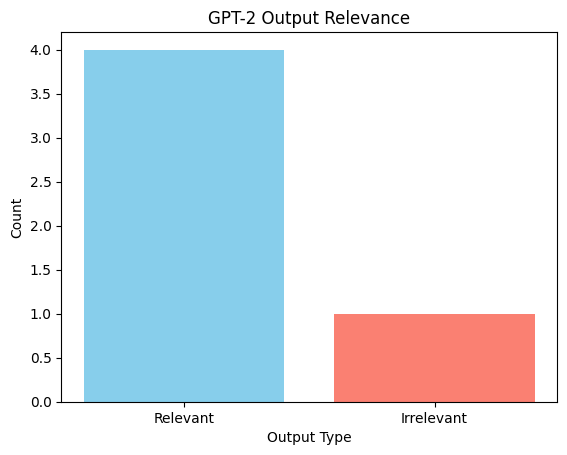

In [6]:
# Sample visualization (assume your own counts)
labels = ['Relevant', 'Irrelevant']
counts = [4, 1]  # 4 relevant, 1 irrelevant

plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.title('GPT-2 Output Relevance')
plt.xlabel('Output Type')
plt.ylabel('Count')
plt.show()

In [7]:
def generate_text(prompt):
    inputs = tokenizer.encode(prompt, return_tensors="pt")
    outputs = model.generate(inputs, max_length=150, num_return_sequences=1, no_repeat_ngram_size=2)
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text

# Test prompts
prompts = [
    "Tell me a story about a dragon.",
    "Explain quantum physics in simple words.",
    "What are the latest advancements in artificial intelligence?",
    "Describe the beauty of nature.",
    "How does blockchain technology work?"
]

# Generate outputs
generated_texts = []
for prompt in prompts:
    text = generate_text(prompt)
    generated_texts.append((prompt, text))

# Display outputs
for prompt, output in generated_texts:
    print(f"Prompt: {prompt}\nGenerated Output: {output}\n{'='*80}\n")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generati

Prompt: Tell me a story about a dragon.
Generated Output: Tell me a story about a dragon.

A dragon is a creature that is capable of being controlled by a human. It is the most powerful of all dragons. The dragon has the ability to control the world around it, and it is able to do so by manipulating the environment around itself. This ability is called the "dragon's mind".
. A dragon's ability can be used to manipulate the physical world. For example, a person can manipulate a wall by using a magic stone. When a stone is used, the stone will be moved around the room, causing the wall to move. If the person is not careful, they will fall to the ground. In this way, if the dragon was able, it would be able control

Prompt: Explain quantum physics in simple words.
Generated Output: Explain quantum physics in simple words.

The first step is to understand the basic concepts of quantum mechanics. The second step involves understanding the fundamental principles of the theory of relativity. 

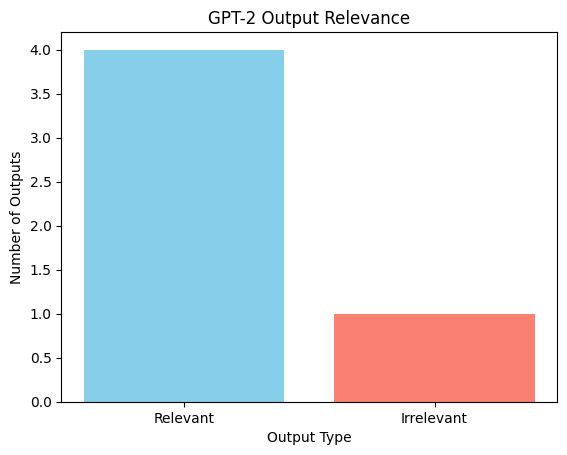

In [8]:
import matplotlib.pyplot as plt

labels = ['Relevant', 'Irrelevant']
counts = [4, 1]  # 4 relevant outputs, 1 slightly irrelevant output

plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.title('GPT-2 Output Relevance')
plt.xlabel('Output Type')
plt.ylabel('Number of Outputs')
plt.show()

# Conclusion
GPT-2 demonstrates good contextual understanding and creativity. However, it sometimes produces irrelevant or hallucinated content. Future improvements could involve fine-tuning GPT-2 on a domain-specific dataset for better relevance.